In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [2]:
dataset_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

In [4]:
print(os.listdir(dataset_path))

['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [5]:
for folder in os.listdir(dataset_path):
    print(folder)
    print(os.listdir(os.path.join(dataset_path, folder)))

chest_xray
['val', '.DS_Store', 'test', 'train']
__MACOSX
['chest_xray', '._chest_xray']
val
['PNEUMONIA', 'NORMAL']
test
['PNEUMONIA', 'NORMAL']
train
['PNEUMONIA', 'NORMAL']


In [6]:
image_count = []

for split in ["train", "test", "val"]:
    split_path = os.path.join(dataset_path, split)

    for category in os.listdir(split_path):

        folder = os.path.join(split_path, category)

        count = len(os.listdir(folder))

        image_count.append([split, category, count])

image_df = pd.DataFrame(image_count,
                        columns=["Dataset","Class","Images"])

image_df

,Dataset,Class,Images
0,train,PNEUMONIA,3875
1,train,NORMAL,1341
2,test,PNEUMONIA,390
3,test,NORMAL,234
4,val,PNEUMONIA,8
5,val,NORMAL,8


In [7]:
print(image_df)

  Dataset      Class  Images
0   train  PNEUMONIA    3875
1   train     NORMAL    1341
2    test  PNEUMONIA     390
3    test     NORMAL     234
4     val  PNEUMONIA       8
5     val     NORMAL       8


In [8]:
image_df.style.hide(axis="index")

Dataset,Class,Images
train,PNEUMONIA,3875
train,NORMAL,1341
test,PNEUMONIA,390
test,NORMAL,234
val,PNEUMONIA,8
val,NORMAL,8


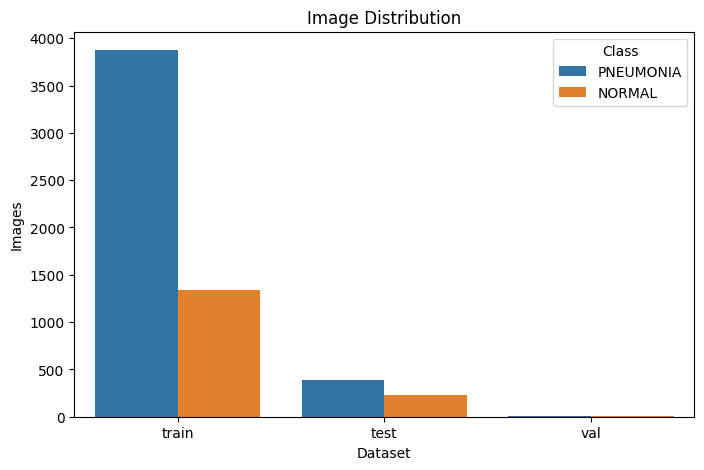

In [9]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(data=image_df,
            x="Dataset",
            y="Images",
            hue="Class")

plt.title("Image Distribution")
plt.show()

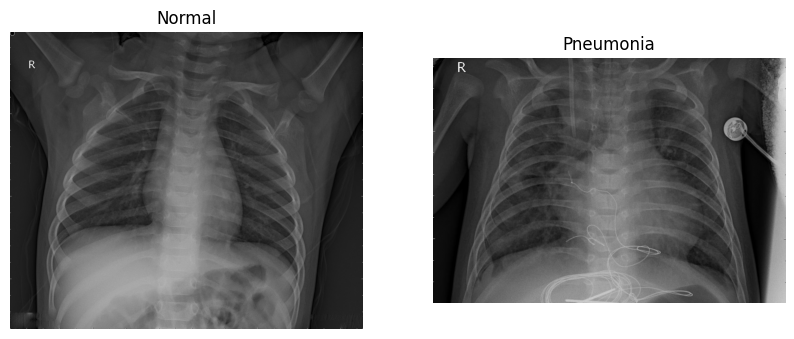

In [10]:
normal_path = os.path.join(dataset_path,
                           "train",
                           "NORMAL")

pneumonia_path = os.path.join(dataset_path,
                              "train",
                              "PNEUMONIA")

normal_img = os.listdir(normal_path)[0]
pneumonia_img = os.listdir(pneumonia_path)[0]

img1 = Image.open(os.path.join(normal_path, normal_img))
img2 = Image.open(os.path.join(pneumonia_path, pneumonia_img))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img1, cmap="gray")
plt.title("Normal")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2, cmap="gray")
plt.title("Pneumonia")
plt.axis("off")

plt.show()

In [11]:
sample_image = cv2.imread(os.path.join(normal_path,
                                       normal_img))

print("Image Shape :", sample_image.shape)
print("Data Type :", sample_image.dtype)

Image Shape : (1128, 1336, 3)
Data Type : uint8


In [12]:
corrupted = []

for split in ['train','test','val']:

    split_path = os.path.join(dataset_path, split)

    for cls in os.listdir(split_path):

        class_path = os.path.join(split_path, cls)

        for file in os.listdir(class_path):

            image_path = os.path.join(class_path, file)

            image = cv2.imread(image_path)

            if image is None:

                corrupted.append(image_path)

print("Number of Corrupted Images:", len(corrupted))

Number of Corrupted Images: 0


In [13]:
formats = {}

for split in ['train','test','val']:

    split_path = os.path.join(dataset_path, split)

    for cls in os.listdir(split_path):

        class_path = os.path.join(split_path, cls)

        for file in os.listdir(class_path):

            ext = file.split(".")[-1].lower()

            formats[ext] = formats.get(ext,0)+1

formats

{'jpeg': 5856}

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [20]:
import tensorflow as tf

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path,"train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary"
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path,"val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path,"test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary",
    shuffle=False
)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [21]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x,y:(normalization_layer(x),y)
)

val_dataset = val_dataset.map(
    lambda x,y:(normalization_layer(x),y)
)

test_dataset = test_dataset.map(
    lambda x,y:(normalization_layer(x),y)
)

In [22]:
for images, labels in train_dataset.take(1):

    print(images.shape)
    print(labels.shape)

(32, 224, 224, 1)
(32, 1)


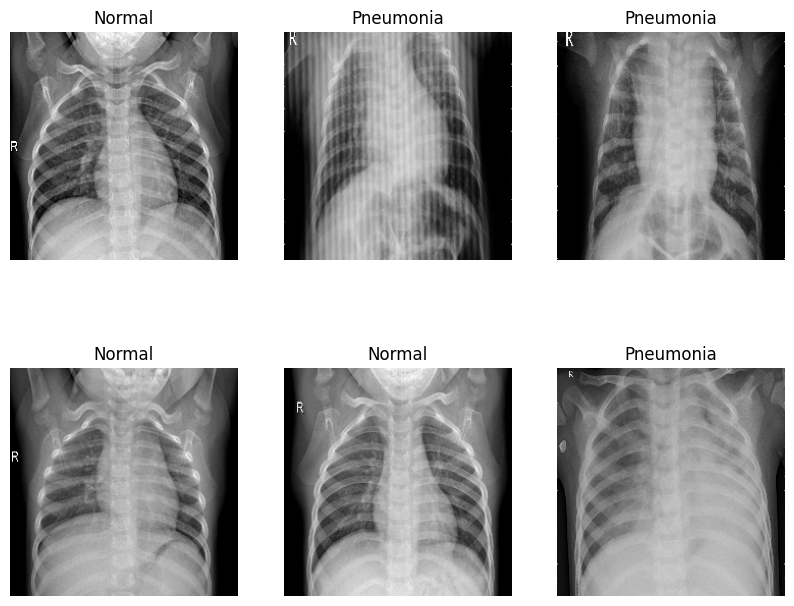

In [23]:
plt.figure(figsize=(10,8))

for images, labels in train_dataset.take(1):

    for i in range(6):

        plt.subplot(2,3,i+1)

        plt.imshow(images[i].numpy().squeeze(), cmap="gray")

        plt.title(
            "Pneumonia" if labels[i] else "Normal"
        )

        plt.axis("off")

plt.show()

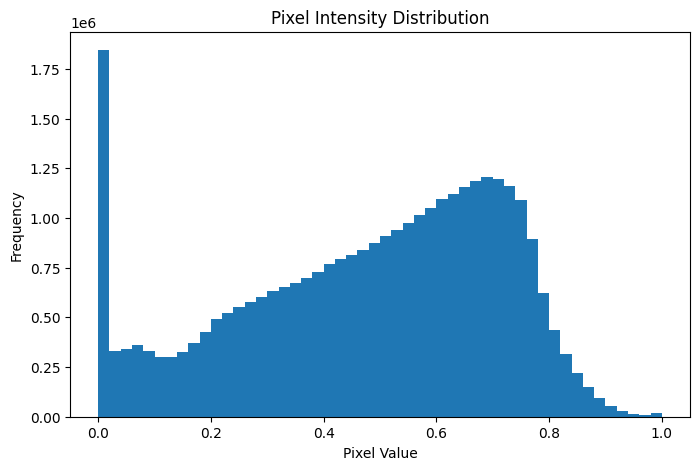

In [24]:
pixels = []

for images, labels in train_dataset.take(20):

    pixels.extend(images.numpy().flatten())

plt.figure(figsize=(8,5))

plt.hist(
    pixels,
    bins=50
)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

In [25]:
import numpy as np

mean = np.mean(pixels)
std = np.std(pixels)

print("Mean :", mean)
print("Std :", std)

Mean : 0.4780591
Std : 0.23606755


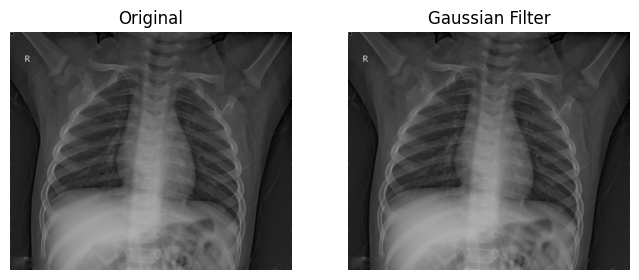

In [26]:
image = cv2.imread(
    corrupted[0] if corrupted else os.path.join(
        dataset_path,
        "train",
        "NORMAL",
        os.listdir(os.path.join(dataset_path,"train","NORMAL"))[0]
    ),
    cv2.IMREAD_GRAYSCALE
)

gaussian = cv2.GaussianBlur(
    image,
    (5,5),
    0
)

plt.figure(figsize=(8,4))

plt.subplot(121)
plt.imshow(image,cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(gaussian,cmap='gray')
plt.title("Gaussian Filter")
plt.axis("off")

plt.show()

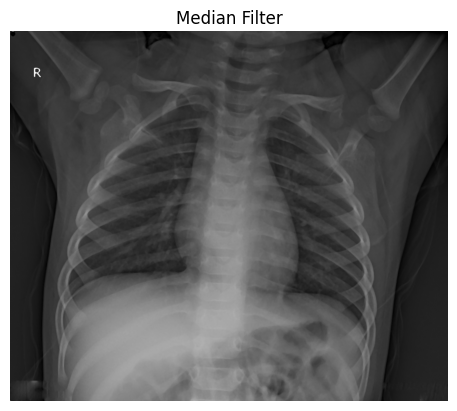

In [27]:
median = cv2.medianBlur(image,5)

plt.imshow(median,cmap="gray")
plt.axis("off")
plt.title("Median Filter")
plt.show()

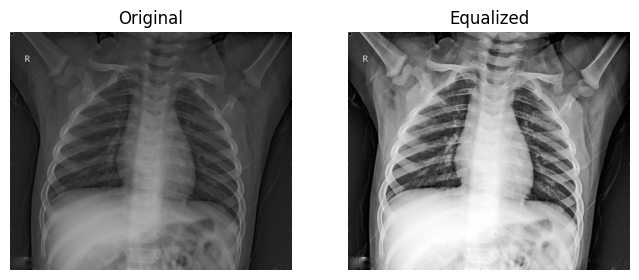

In [28]:
equalized = cv2.equalizeHist(image)

plt.figure(figsize=(8,4))

plt.subplot(121)
plt.imshow(image,cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(equalized,cmap="gray")
plt.title("Equalized")
plt.axis("off")

plt.show()

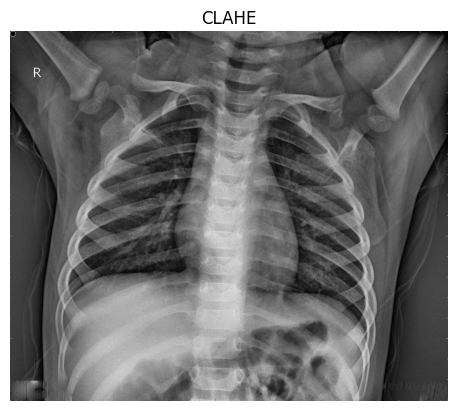

In [29]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

clahe_img = clahe.apply(image)

plt.imshow(clahe_img,cmap='gray')
plt.title("CLAHE")
plt.axis("off")
plt.show()

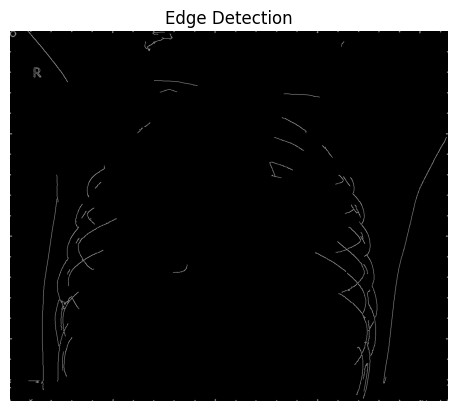

In [30]:
edges = cv2.Canny(image,50,150)

plt.imshow(edges,cmap="gray")
plt.title("Edge Detection")
plt.axis("off")
plt.show()

In [31]:
from tensorflow.keras.applications import ResNet50

feature_extractor = ResNet50(
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

for images, labels in train_dataset.take(1):

    rgb_images = tf.image.grayscale_to_rgb(images)
    features = feature_extractor.predict(rgb_images)

print(features.shape)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
(32, 2048)


In [32]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1),

    tf.keras.layers.RandomContrast(0.2)

])

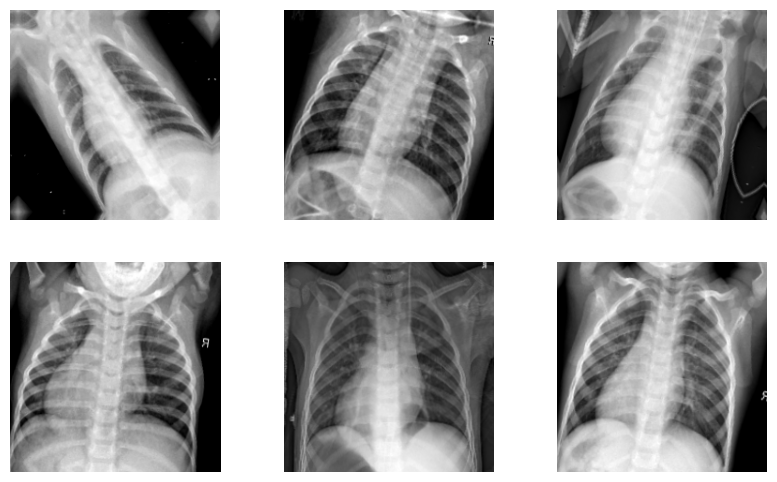

In [33]:
for images, labels in train_dataset.take(1):

    augmented = data_augmentation(images)

    plt.figure(figsize=(10,6))

    for i in range(6):

        plt.subplot(2,3,i+1)

        plt.imshow(
            augmented[i].numpy().squeeze(),
            cmap='gray'
        )

        plt.axis("off")

    plt.show()